# Analysis

## Tree

In [2]:
import os

def print_tree(start_path, max_depth=3):
    start_path = os.path.abspath(start_path)

    for root, dirs, files in os.walk(start_path):
        level = root.replace(start_path, "").count(os.sep)
        
        if level > max_depth:
            continue
        
        indent = "│   " * level
        print(f"{indent}├── {os.path.basename(root)}/")
        
        sub_indent = "│   " * (level + 1)
        for f in files:
            print(f"{sub_indent}├── {f}")

# 현재 위치 기준 실행
print_tree(".", max_depth=3)

├── sub_experiment/
│   ├── analysis.ipynb
│   ├── data_prep.py
│   ├── data_shape.ipynb
│   ├── model_base_BERT.ipynb
│   ├── model_BiomedBERT.ipynb
│   ├── model_BiomedBERT_weighted_CE.ipynb
│   ├── data/
│   │   ├── id2label_top50.json
│   │   ├── label2id_top50.json
│   │   ├── label_mapping_top50.csv
│   │   ├── preprocessed_data_49633.csv
│   │   ├── raw_data_49637.csv
│   │   ├── test_50_2476.csv
│   │   ├── total_50_24754.csv
│   │   ├── train_50_19803.csv
│   │   ├── val_50_2475.csv
│   │   ├── shape/
│   │   │   ├── basic_sanity_check.csv
│   │   │   ├── filtered_text_length_summary.csv
│   │   │   ├── ratio_comparison_vs_total.csv
│   │   │   ├── ratio_summary_vs_total.csv
│   │   │   ├── split_text_overlap_check.csv
│   │   │   ├── test_dist.csv
│   │   │   ├── test_dist.png
│   │   │   ├── test_dist.txt
│   │   │   ├── total_dist.csv
│   │   │   ├── total_dist.png
│   │   │   ├── total_dist.txt
│   │   │   ├── train_dist.csv
│   │   │   ├── train_dist.png
│   │   │   ├── t

## setup

In [41]:
import os
import json
import matplotlib.pyplot as plt

In [42]:
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, 'data')
MODEL_DIR = os.path.join(BASE_DIR, 'models')
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')

In [43]:
BASE_DIR, DATA_DIR, MODEL_DIR, OUTPUT_DIR

('c:\\Users\\Minkyu Ham\\Desktop\\stat359\\student\\final_project\\clinical_note_icd_llm\\sub_experiment',
 'c:\\Users\\Minkyu Ham\\Desktop\\stat359\\student\\final_project\\clinical_note_icd_llm\\sub_experiment\\data',
 'c:\\Users\\Minkyu Ham\\Desktop\\stat359\\student\\final_project\\clinical_note_icd_llm\\sub_experiment\\models',
 'c:\\Users\\Minkyu Ham\\Desktop\\stat359\\student\\final_project\\clinical_note_icd_llm\\sub_experiment\\outputs')

## RQ1
### Graph

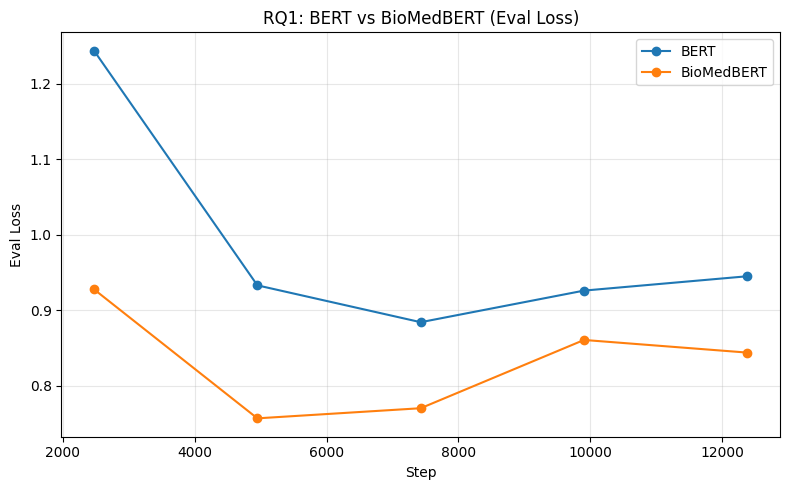

Saved to: c:\Users\Minkyu Ham\Desktop\stat359\student\final_project\clinical_note_icd_llm\sub_experiment\outputs\rq1_eval_loss.png


In [44]:
import os
import json
import matplotlib.pyplot as plt

# 경로
base_path = os.path.join(OUTPUT_DIR, "base_bert_ce", "trainer_log_history.json")
biomed_path = os.path.join(OUTPUT_DIR, "biomed_bert_ce", "trainer_log_history.json")

# json 로드
with open(base_path, "r") as f:
    base_logs = json.load(f)

with open(biomed_path, "r") as f:
    biomed_logs = json.load(f)

# step 중복 제거 (같은 step이면 마지막 값 사용)
base_dict = {}
for log in base_logs:
    if "eval_loss" in log:
        base_dict[log["step"]] = log["eval_loss"]

biomed_dict = {}
for log in biomed_logs:
    if "eval_loss" in log:
        biomed_dict[log["step"]] = log["eval_loss"]

# 정렬
base_steps = sorted(base_dict.keys())
base_loss = [base_dict[s] for s in base_steps]

biomed_steps = sorted(biomed_dict.keys())
biomed_loss = [biomed_dict[s] for s in biomed_steps]

# 그래프
plt.figure(figsize=(8, 5))

plt.plot(base_steps, base_loss, marker='o', label="BERT")
plt.plot(biomed_steps, biomed_loss, marker='o', label="BioMedBERT")

plt.title("RQ1: BERT vs BioMedBERT (Eval Loss)")
plt.xlabel("Step")
plt.ylabel("Eval Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

# 저장 경로
save_path = os.path.join(OUTPUT_DIR, "rq1_eval_loss.png")

# 저장
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved to: {save_path}")

### Table

In [45]:
import os
import json
import pandas as pd

# 경로
base_path = os.path.join(OUTPUT_DIR, "base_bert_ce", "test_metrics.json")
biomed_path = os.path.join(OUTPUT_DIR, "biomed_bert_ce", "test_metrics.json")

# 로드
with open(base_path, "r") as f:
    base_metrics = json.load(f)

with open(biomed_path, "r") as f:
    biomed_metrics = json.load(f)

# 표 생성
data = [
    {
        "Model": "BERT",
        "Macro F1": base_metrics["eval_macro_f1"],
        "Top-1": base_metrics["eval_accuracy"],   # ← 여기 중요
        "Top-3": base_metrics["eval_hit@3"],
        "Top-5": base_metrics["eval_hit@5"],
    },
    {
        "Model": "BioMedBERT",
        "Macro F1": biomed_metrics["eval_macro_f1"],
        "Top-1": biomed_metrics["eval_accuracy"],
        "Top-3": biomed_metrics["eval_hit@3"],
        "Top-5": biomed_metrics["eval_hit@5"],
    }
]

df = pd.DataFrame(data).round(4)

print("\n   ========= Test Evaluation Results ==========")
df


   ========= Test Evaluation Results ==========


,Model,Macro F1,Top-1,Top-3,Top-5
0,BERT,0.7655,0.7686,0.9168,0.9548
1,BioMedBERT,0.7915,0.7936,0.9402,0.9709


### Tokenizer

In [46]:
import os
import pandas as pd
from transformers import AutoTokenizer

# 1. tokenizer 로드
bert_tokenizer = AutoTokenizer.from_pretrained(
    os.path.join(MODEL_DIR, "base_bert_ce")
)

biomed_tokenizer = AutoTokenizer.from_pretrained(
    os.path.join(MODEL_DIR, "biomed_bert_ce")
)

# 2. 예시 데이터 불러오기
test_df = pd.read_csv(os.path.join(DATA_DIR, "test_50_2476.csv"))

# 3. 예시 문장 하나 선택
sample_text = test_df.loc[0, "filtered_text"]   # 컬럼명이 text가 아니면 바꿔야 함

print("=== Sample Text ===")
print(sample_text[:1000])  # 너무 길면 앞부분만 출력
print()

# 4. 토큰화
bert_tokens = bert_tokenizer.tokenize(sample_text)
biomed_tokens = biomed_tokenizer.tokenize(sample_text)

# 5. 결과 출력
print("=== BERT Tokens (first 50) ===")
print(bert_tokens[:50])
print("Token count:", len(bert_tokens))
print()

print("=== BioMedBERT Tokens (first 50) ===")
print(biomed_tokens[:50])
print("Token count:", len(biomed_tokens))
print()

comparison_df = pd.DataFrame({
    "Model": ["BERT", "BioMedBERT"],
    "Token Count": [len(bert_tokens), len(biomed_tokens)],
    "First 20 Tokens": [
        " ".join(bert_tokens[:20]),
        " ".join(biomed_tokens[:20]),
    ]
})

comparison_df

=== Sample Text ===
Increased shortness of breath and sputum production.

Patient is a female with a history of COPD on home oxygen, tracheobronchomalacia s/p stent, NSCLC s/p CyberKnife, hypogammaglobulinemia, HFpEF, CAD s/p PCI, presenting with one week of worsening cough, dyspnea, and green sputum production. Symptoms worsened yesterday with dyspnea on exertion. Patient is on chronic steroids and home oxygen (3L). Recent tracheal stent placement last week.

Admitted for acute COPD exacerbation and acute tracheobronchitis. Patient received IV antibiotics (Zosyn), IV steroids (prednisone taper initiated), nebulized bronchodilators, and airway clearance therapies. IVIG administered for hypogammaglobulinemia. Patient improved clinically to baseline status on 3L O2.

=== BERT Tokens (first 50) ===
['increased', 'short', '##ness', 'of', 'breath', 'and', 'sp', '##ut', '##um', 'production', '.', 'patient', 'is', 'a', 'female', 'with', 'a', 'history', 'of', 'cop', '##d', 'on', 'home', 'oxyge

,Model,Token Count,First 20 Tokens
0,BERT,212,increased short ##ness of breath and sp ##ut #...
1,BioMedBERT,161,increased short ##ness of breath and sputum pr...


In [47]:
from transformers import AutoTokenizer
import os
import pandas as pd

# tokenizer 로드
bert_tokenizer = AutoTokenizer.from_pretrained(
    os.path.join(MODEL_DIR, "base_bert_ce")
)

biomed_tokenizer = AutoTokenizer.from_pretrained(
    os.path.join(MODEL_DIR, "biomed_bert_ce")
)

# 비교할 clinical terms
terms = [
    "NSTEMI",
    "ureteral",
    "stenting",
    "HTN",
    "nephrolithiasis",
    "urosepsis",
    "troponins",
    "catheterization",
    "CABG",
    "hydronephrosis",
]

rows = []

for term in terms:
    bert_split = bert_tokenizer.tokenize(term)
    biomed_split = biomed_tokenizer.tokenize(term)

    rows.append({
        "Term": term,
        "BERT Tokens": " / ".join(bert_split),
        "BERT Count": len(bert_split),
        "BioMedBERT Tokens": " / ".join(biomed_split),
        "BioMedBERT Count": len(biomed_split),
    })

token_compare_df = pd.DataFrame(rows)
token_compare_df

,Term,BERT Tokens,BERT Count,BioMedBERT Tokens,BioMedBERT Count
0,NSTEMI,ns / ##tem / ##i,3,ns / ##te / ##mi,3
1,ureteral,ur / ##eter / ##al,3,ureteral,1
2,stenting,ste / ##nting,2,stenting,1
3,HTN,h / ##t / ##n,3,htn,1
4,nephrolithiasis,ne / ##ph / ##rol / ##ith / ##ias / ##is,6,neph / ##rol / ##ithiasis,3
5,urosepsis,ur / ##ose / ##psis,3,uro / ##se / ##ps / ##is,4
6,troponins,tr / ##op / ##oni / ##ns,4,troponin / ##s,2
7,catheterization,cat / ##het / ##eri / ##zation,4,catheterization,1
8,CABG,cab / ##g,2,cabg,1
9,hydronephrosis,hydro / ##ne / ##ph / ##rosis,4,hydro / ##ne / ##ph / ##rosis,4


In [48]:
print("BERT avg token length:", len(bert_tokens))
print("BioMedBERT avg token length:", len(biomed_tokens))

BERT avg token length: 212
BioMedBERT avg token length: 161


## RQ2
### Graph

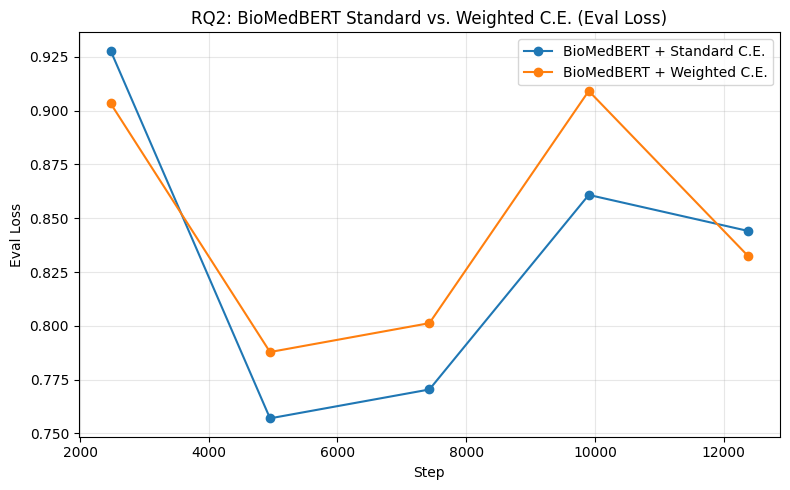

Saved to: c:\Users\Minkyu Ham\Desktop\stat359\student\final_project\clinical_note_icd_llm\sub_experiment\outputs\rq2_eval_loss.png


In [51]:
import os
import json
import matplotlib.pyplot as plt

# 경로
biomed_standard_path = os.path.join(OUTPUT_DIR, "biomed_bert_ce", "trainer_log_history.json")
biomed_weighted_path = os.path.join(OUTPUT_DIR, "biomed_bert_weighted_ce", "trainer_log_history.json")

# json 로드
with open(biomed_standard_path, "r") as f:
    biomed_standard_logs = json.load(f)

with open(biomed_weighted_path, "r") as f:
    biomed_weighted_logs = json.load(f)

# step 중복 제거 (같은 step이면 마지막 값 사용)
biomed_standard_dict = {}
for log in biomed_standard_logs:
    if "eval_loss" in log:
        biomed_standard_dict[log["step"]] = log["eval_loss"]

biomed_weighted_dict = {}
for log in biomed_weighted_logs:
    if "eval_loss" in log:
        biomed_weighted_dict[log["step"]] = log["eval_loss"]

# 정렬
biomed_standard_steps = sorted(biomed_standard_dict.keys())
biomed_standard_loss = [biomed_standard_dict[s] for s in biomed_standard_steps]

biomed_weighted_steps = sorted(biomed_weighted_dict.keys())
biomed_weighted_loss = [biomed_weighted_dict[s] for s in biomed_weighted_steps]

# 그래프
plt.figure(figsize=(8, 5))

plt.plot(biomed_standard_steps, biomed_standard_loss, marker='o', label="BioMedBERT + Standard C.E.")
plt.plot(biomed_weighted_steps, biomed_weighted_loss, marker='o', label="BioMedBERT + Weighted C.E.")

plt.title("RQ2: BioMedBERT Standard vs. Weighted C.E. (Eval Loss)")
plt.xlabel("Step")
plt.ylabel("Eval Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

# 저장 경로
save_path = os.path.join(OUTPUT_DIR, "rq2_eval_loss.png")

# 저장
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved to: {save_path}")

### Table

In [50]:
import os
import json
import pandas as pd

# 경로
biomed_standard_path = os.path.join(OUTPUT_DIR, "biomed_bert_ce", "test_metrics.json")
biomed_weighted_path = os.path.join(OUTPUT_DIR, "biomed_bert_weighted_ce", "test_metrics.json")

# json 로드
with open(biomed_standard_path, "r") as f:
    biomed_standard_metrics = json.load(f)

with open(biomed_weighted_path, "r") as f:
    biomed_weighted_metrics = json.load(f)

# 표 생성
data = [
    {
        "Model": "BioMedBERT + Standard C.E.",
        "Macro F1": biomed_standard_metrics["eval_macro_f1"],
        "Top-1": biomed_standard_metrics["eval_accuracy"],   # ← 여기 중요
        "Top-3": biomed_standard_metrics["eval_hit@3"],
        "Top-5": biomed_standard_metrics["eval_hit@5"],
    },
    {
        "Model": "BioMedBERT + Weighted C.E,",
        "Macro F1": biomed_weighted_metrics["eval_macro_f1"],
        "Top-1": biomed_weighted_metrics["eval_accuracy"],
        "Top-3": biomed_weighted_metrics["eval_hit@3"],
        "Top-5": biomed_weighted_metrics["eval_hit@5"],
    }
]

df = pd.DataFrame(data).round(4)

print("\n   ========= Test Evaluation Results ==========")
df


   ========= Test Evaluation Results ==========


,Model,Macro F1,Top-1,Top-3,Top-5
0,BioMedBERT + Standard C.E.,0.7915,0.7936,0.9402,0.9709
1,"BioMedBERT + Weighted C.E,",0.7920,0.7904,0.9346,0.9657


## Class-wise F1

['reformulation', 'icd_code', 'filtered_text', 'major_code', 'labels']
texts: 2476
y_true shape: (2476,)


,label,precision,recall,f1,support
0,A41,0.888889,0.701031,0.783862,194.0
10,I21,0.845455,0.861111,0.853211,108.0
49,Z51,0.989474,0.969072,0.979167,97.0
11,I25,0.884615,0.734043,0.802326,94.0
9,I13,0.600000,0.662791,0.629834,86.0
17,I63,0.958904,0.886076,0.921053,79.0
4,E11,0.837838,0.837838,0.837838,74.0
37,N17,0.757576,0.714286,0.735294,70.0
28,K80,0.862745,0.666667,0.752137,66.0
21,J18,0.796875,0.822581,0.809524,62.0


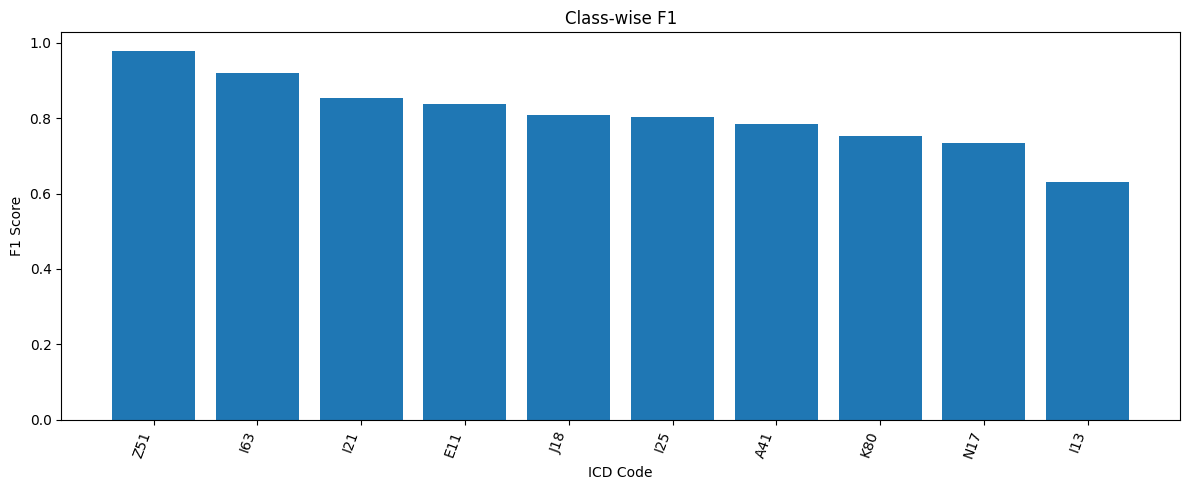

Saved to: c:\Users\Minkyu Ham\Desktop\stat359\student\final_project\clinical_note_icd_llm\sub_experiment\outputs\biomed_bert_weighted_ce_classwise_f1_top10.png


In [40]:
import os
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report

CNT = 10

# ===== 설정 =====
MODEL_NAME = "biomed_bert_weighted_ce"
MODEL_PATH = os.path.join(MODEL_DIR, MODEL_NAME)
TEST_PATH = os.path.join(DATA_DIR, "test_50_2476.csv")
ID2LABEL_PATH = os.path.join(DATA_DIR, "id2label_top50.json")

# ===== 데이터 로드 =====
test_df = pd.read_csv(TEST_PATH)

with open(ID2LABEL_PATH, "r", encoding="utf-8") as f:
    id2label = json.load(f)

texts = test_df["filtered_text"].fillna("").tolist()
y_true = test_df["labels"].astype(int).to_numpy()

print(test_df.columns.tolist())
print("texts:", len(texts))
print("y_true shape:", y_true.shape)

# ===== 모델 로드 =====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH).to(device)
model.eval()

# ===== 예측 =====
all_preds = []

with torch.no_grad():
    for i in range(0, len(texts), 8):
        batch_texts = texts[i:i+8]
        enc = tokenizer(
            batch_texts,
            truncation=True,
            padding=True,
            max_length=512,
            return_tensors="pt"
        ).to(device)

        logits = model(**enc).logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)

y_pred = np.array(all_preds)

# ===== class-wise report =====
report = classification_report(
    y_true,
    y_pred,
    labels=list(range(len(id2label))),
    target_names=[id2label[str(i)] for i in range(len(id2label))],
    output_dict=True,
    zero_division=0
)

classwise_df = pd.DataFrame(report).T.iloc[:-3].reset_index()
classwise_df.columns = ["label", "precision", "recall", "f1", "support"]
classwise_df = classwise_df.sort_values("support", ascending=False)

display(classwise_df)

# ===== 그래프 =====
plot_df = classwise_df.head(CNT).sort_values("f1", ascending=False)

plt.figure(figsize=(12, 5))
plt.bar(plot_df["label"], plot_df["f1"])
plt.title(f"Class-wise F1")
plt.xlabel("ICD Code")
plt.ylabel("F1 Score")
plt.xticks(rotation=70, ha="right")
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, f"{MODEL_NAME}_classwise_f1_top{CNT}.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {save_path}")

## Confusion Metrics

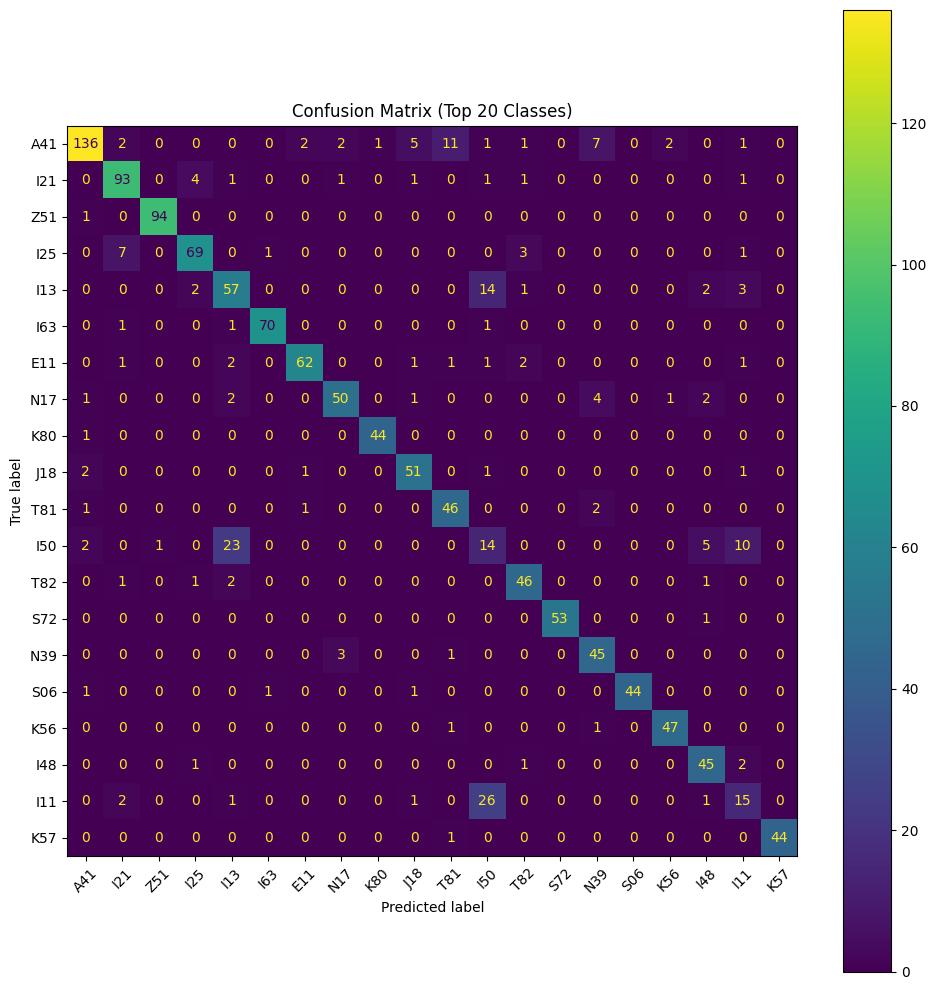

Saved to: c:\Users\Minkyu Ham\Desktop\stat359\student\final_project\clinical_note_icd_llm\sub_experiment\outputs\biomed_bert_weighted_ce_confusion_matrix_top20.png


In [38]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

CNT = 20

top_df = classwise_df.sort_values("support", ascending=False).head(CNT)
top_codes = top_df["label"].tolist()

code_to_id = {id2label[str(i)]: i for i in range(len(id2label))}
top_ids = [code_to_id[c] for c in top_codes]

mask = np.isin(y_true, top_ids)
y_true_top = y_true[mask]
y_pred_top = y_pred[mask]

cm = confusion_matrix(y_true_top, y_pred_top, labels=top_ids)

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_codes)
disp.plot(ax=ax, xticks_rotation=45, values_format="d")
plt.title(f"Confusion Matrix (Top {CNT} Classes)")
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, f"{MODEL_NAME}_confusion_matrix_top{CNT}.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved to: {save_path}")

## Results

In [46]:
import os
import json
import pandas as pd

# 경로
paths = {
    "BERT + CE": os.path.join(OUTPUT_DIR, "base_bert_ce", "test_metrics.json"),
    "BioMedBERT + CE": os.path.join(OUTPUT_DIR, "biomed_bert_ce", "test_metrics.json"),
    "BioMedBERT + Weighted CE": os.path.join(OUTPUT_DIR, "biomed_bert_weighted_ce", "test_metrics.json"),
}

rows = []

for name, path in paths.items():
    with open(path, "r") as f:
        m = json.load(f)

    rows.append({
        "Model": name,
        "Macro F1": m["eval_macro_f1"],
        "Top-1": m["eval_accuracy"],
        "Top-3": m["eval_hit@3"],
        "Top-5": m["eval_hit@5"],
    })

df = pd.DataFrame(rows)

# 소수점 정리
df = df.round(4)

# ===== best 값 bold 표시용 (optional) =====
def highlight_max(s):
    is_max = s == s.max()
    return ["font-weight: bold" if v else "" for v in is_max]

styled_df = df.style.apply(highlight_max, subset=["Macro F1", "Top-1", "Top-3", "Top-5"])

display(styled_df)

# ===== 저장 =====
save_path = os.path.join(OUTPUT_DIR, "overall_results.csv")
df.to_csv(save_path, index=False)

print(f"Saved to: {save_path}")

,Model,Macro F1,Top-1,Top-3,Top-5
0,BERT + CE,0.779700,0.780800,0.936900,0.958000
1,BioMedBERT + CE,0.825900,0.827800,0.960000,0.975000
2,BioMedBERT + Weighted CE,0.823100,0.824800,0.946900,0.969000


Saved to: c:\Users\Minkyu Ham\Desktop\stat359\student\final_project\clinical_note_icd_llm\outputs\overall_results.csv


In [55]:
import os

BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, 'data')

BASE_DIR, DATA_DIR

('c:\\Users\\Minkyu Ham\\Desktop\\stat359\\student\\final_project\\clinical_note_icd_llm\\sub_experiment',
 'c:\\Users\\Minkyu Ham\\Desktop\\stat359\\student\\final_project\\clinical_note_icd_llm\\sub_experiment\\data')

In [60]:
import pandas as pd
import re
from collections import Counter

# ===== 데이터 로드 =====
df = pd.read_csv(os.path.join(DATA_DIR, "test_50_2476.csv"))

# ===== I 계열 필터링 =====
# label이 문자열이면 그대로, 숫자면 id2label 필요
# 여기서는 코드 컬럼이 있다고 가정
df["major_code"] = df["major_code"].astype(str)

i_df = df[df["major_code"].str.startswith("I")]

print("I-series count:", len(i_df))

# ===== 텍스트 전처리 =====
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)  # 특수문자 제거
    tokens = text.split()
    return tokens

# ===== 모든 단어 모으기 =====
all_words = []

for text in i_df["filtered_text"].fillna(""):
    tokens = clean_text(text)
    all_words.extend(tokens)

# ===== 불용어 제거 (간단 버전) =====
stopwords = set([
    "the", "and", "of", "to", "in", "a", "with", "for",
    "on", "at", "by", "is", "was", "as", "an", "be"
])

filtered_words = [w for w in all_words if w not in stopwords and len(w) > 2]

# ===== 단어 빈도 계산 =====
word_counts = Counter(filtered_words)

# ===== 상위 단어 출력 =====
top_words = word_counts.most_common(20)

print("\nTop frequent words in I-series:")
for word, count in top_words:
    print(f"{word}: {count}")

I-series count: 705

Top frequent words in I-series:
patient: 1927
pain: 932
history: 857
chest: 809
admitted: 637
acute: 604
presented: 572
showed: 555
left: 506
she: 457
right: 452
hypertension: 439
prior: 408
atrial: 404
dyspnea: 385
revealed: 382
failure: 369
heart: 362
disease: 353
chronic: 341


In [61]:
keywords = ["chest", "pain", "heart", "cardiac", "hypertension", "failure"]

for k in keywords:
    print(k, word_counts[k])

chest 809
pain 932
heart 362
cardiac 314
hypertension 439
failure 369


In [62]:
from nltk import bigrams

bigrams_list = list(bigrams(filtered_words))
bigram_counts = Counter(bigrams_list)

print("\nTop bigrams:")
for (w1, w2), count in bigram_counts.most_common(15):
    print(f"{w1} {w2}: {count}")


Top bigrams:
chest pain: 557
atrial fibrillation: 332
patient admitted: 287
heart failure: 282
male history: 248
shortness breath: 246
coronary artery: 222
cardiac catheterization: 213
year old: 200
female history: 187
patient history: 173
artery disease: 153
acute chronic: 139
who presented: 137
admitted acute: 132


In [63]:
from collections import Counter
from nltk import bigrams

bigram_doc_counts = Counter()

for text in i_df["filtered_text"].fillna(""):
    tokens = clean_text(text)
    bg = set(bigrams(tokens))  # 문서 단위 중복 제거
    bigram_doc_counts.update(bg)

N = len(i_df)

common_bigrams = []

for (w1, w2), count in bigram_doc_counts.items():
    ratio = count / N
    if ratio > 0.1:   # 10% 이상 등장
        common_bigrams.append((f"{w1} {w2}", count, ratio))

common_bigrams = sorted(common_bigrams, key=lambda x: x[2], reverse=True)

for bg, count, ratio in common_bigrams[:15]:
    print(f"{bg}: {count} docs ({ratio:.2f})")

history of: 654 docs (0.93)
with a: 516 docs (0.73)
a history: 508 docs (0.72)
admitted for: 442 docs (0.63)
is a: 354 docs (0.50)
patient is: 344 docs (0.49)
presented with: 323 docs (0.46)
chest pain: 306 docs (0.43)
male with: 260 docs (0.37)
patient admitted: 250 docs (0.35)
due to: 236 docs (0.33)
s p: 236 docs (0.33)
atrial fibrillation: 216 docs (0.31)
heart failure: 201 docs (0.29)
year old: 200 docs (0.28)


In [65]:
target_codes = ["I13", "I50", "I11"]

subset_df = df[df["major_code"].isin(target_codes)]

print("Subset size:", len(subset_df))
print(subset_df["major_code"].value_counts())

Subset size: 193
major_code
I13    86
I50    58
I11    49
Name: count, dtype: int64


In [66]:
from collections import Counter
from nltk import bigrams
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    return text.split()

bigram_doc_counts = Counter()

for text in subset_df["filtered_text"].fillna(""):
    tokens = clean_text(text)
    bg = set(bigrams(tokens))  # 문서 기준 중복 제거
    bigram_doc_counts.update(bg)

N = len(subset_df)

results = []

for (w1, w2), count in bigram_doc_counts.items():
    ratio = count / N
    if ratio > 0.15:   # threshold (조절 가능)
        results.append((f"{w1} {w2}", count, ratio))

results = sorted(results, key=lambda x: x[2], reverse=True)

for r in results[:20]:
    print(r)

('history of', 185, 0.9585492227979274)
('heart failure', 144, 0.7461139896373057)
('admitted for', 139, 0.7202072538860104)
('with a', 130, 0.6735751295336787)
('a history', 129, 0.6683937823834197)
('presented with', 111, 0.5751295336787565)
('for acute', 107, 0.5544041450777202)
('s p', 96, 0.49740932642487046)
('on chronic', 91, 0.47150259067357514)
('acute on', 89, 0.46113989637305697)
('chest pain', 88, 0.45595854922279794)
('shortness of', 81, 0.41968911917098445)
('of breath', 81, 0.41968911917098445)
('patient admitted', 79, 0.40932642487046633)
('with iv', 79, 0.40932642487046633)
('patient with', 71, 0.36787564766839376)
('failure exacerbation', 70, 0.3626943005181347)
('atrial fibrillation', 70, 0.3626943005181347)
('due to', 69, 0.35751295336787564)
('transitioned to', 68, 0.35233160621761656)


In [67]:
class_bigram = {}

for code in target_codes:
    sub = df[df["major_code"] == code]
    counter = Counter()

    for text in sub["filtered_text"].fillna(""):
        tokens = clean_text(text)
        bg = set(bigrams(tokens))
        counter.update(bg)

    N = len(sub)
    ratios = {f"{w1} {w2}": c/N for (w1, w2), c in counter.items()}
    class_bigram[code] = ratios

In [68]:
common_terms = set(class_bigram[target_codes[0]].keys())

for code in target_codes[1:]:
    common_terms &= set(class_bigram[code].keys())

print("Common terms across classes:", list(common_terms)[:20])

Common terms across classes: ['chest pain', 'worsened by', 'cough or', 'mitral regurgitation', 'atrial flutter', 'improved clinically', 'one week', 'by hypotension', 'lisinopril was', 'dietary indiscretion', 'metoprolol succinate', 'and transferred', 'lisinopril and', 'morbid obesity', 'troponins were', 'diabetes hyperlipidemia', 'of copd', 'with hypoxia', 'extremity edema', 'chronic conditions']


In [69]:
rows = []

for term in common_terms:
    row = [term]
    for code in target_codes:
        row.append(class_bigram[code].get(term, 0))
    rows.append(row)

import pandas as pd
compare_df = pd.DataFrame(rows, columns=["term"] + target_codes)
compare_df = compare_df.sort_values(by=target_codes, ascending=False)

display(compare_df.head(10))

,term,I13,I50,I11
264,history of,0.976744,0.948276,0.938776
738,heart failure,0.744186,0.724138,0.775510
52,admitted for,0.732558,0.620690,0.816327
490,with a,0.662791,0.672414,0.693878
232,a history,0.662791,0.672414,0.673469
799,presented with,0.558140,0.620690,0.551020
635,for acute,0.511628,0.534483,0.653061
38,on chronic,0.500000,0.448276,0.448980
457,s p,0.488372,0.586207,0.408163
327,acute on,0.488372,0.448276,0.428571


In [70]:
import os
import re
import pandas as pd

# ===== 데이터 로드 =====
test_path = os.path.join(DATA_DIR, "test_50_2476.csv")
df = pd.read_csv(test_path)

# ===== 혼동이 컸던 코드만 필터링 =====
target_codes = ["I50", "I13", "I11"]
subset_df = df[df["major_code"].isin(target_codes)].copy()

# ===== 순환기계 관련 의학용어/표현 사전 =====
# 필요하면 여기만 추가/수정하면 됨
cardio_terms = {
    "chest pain": [r"\bchest pain\b"],
    "heart failure": [r"\bheart failure\b"],
    "atrial fibrillation": [r"\batrial fibrillation\b", r"\bafib\b", r"\ba fib\b"],
    "atrial flutter": [r"\batrial flutter\b"],
    "hypertension": [r"\bhypertension\b", r"\bhtn\b"],
    "cardiac": [r"\bcardiac\b"],
    "coronary artery disease": [r"\bcoronary artery disease\b", r"\bcad\b"],
    "coronary artery": [r"\bcoronary artery\b"],
    "troponin": [r"\btroponin\b", r"\btroponins\b"],
    "mitral regurgitation": [r"\bmitral regurgitation\b"],
    "edema": [r"\bedema\b", r"\bextremity edema\b", r"\blower extremity edema\b"],
    "shortness of breath": [r"\bshortness of breath\b", r"\bsob\b", r"\bdyspnea\b"],
    "cardiac catheterization": [r"\bcardiac catheterization\b", r"\bcatheterization\b"],
    "metoprolol": [r"\bmetoprolol\b", r"\bmetoprolol succinate\b"],
    "lisinopril": [r"\blisinopril\b"],
}

# ===== 전처리 =====
subset_df["filtered_text"] = subset_df["filtered_text"].fillna("").astype(str).str.lower()

# ===== 문서 수 =====
total_docs = len(subset_df)

# ===== 각 용어별 등장 문서 수 / 비율 계산 =====
rows = []

for term_name, patterns in cardio_terms.items():
    matched = subset_df["filtered_text"].apply(
        lambda text: any(re.search(pattern, text) for pattern in patterns)
    )
    doc_count = int(matched.sum())
    ratio = doc_count / total_docs if total_docs > 0 else 0.0

    rows.append({
        "term": term_name,
        "docs": doc_count,
        "ratio": round(ratio, 4)
    })

result_df = pd.DataFrame(rows).sort_values(
    by=["docs", "ratio", "term"], ascending=[False, False, True]
).reset_index(drop=True)

display(result_df)

,term,docs,ratio
0,shortness of breath,168,0.8705
1,heart failure,144,0.7461
2,hypertension,138,0.7150
3,edema,107,0.5544
4,chest pain,88,0.4560
5,coronary artery disease,86,0.4456
6,atrial fibrillation,84,0.4352
7,metoprolol,45,0.2332
8,lisinopril,40,0.2073
9,troponin,39,0.2021
